# IoT sensor

A real sensor feed is more than a clean signal: it drifts as the device ages, grows noisier as the battery drains, and occasionally fails. `IoTSensorGenerator` reproduces these artifacts so you can test monitoring and anomaly-detection pipelines against realistic device behavior.

::: {.callout-note}
## The model

A baseline signal is corrupted by calibration `drift_rate`, `battery_degradation_rate`, and intermittent or permanent faults set by `failure_probability` and `failure_type`. Leave them at zero for a healthy sensor, or turn them up to simulate a degrading or failing one.
:::

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import IoTSensorGenerator

## 1. Temperature sensor with gradual drift

Simulate a temperature sensor that gradually drifts over time due to calibration issues.

In [ ]:
params_temp = {
    "min_length": 500,
    "max_length": 500,
    "freq": "min",
    "n_sensors": 1,
    "sensor_type": "temperature",
    "base_value": 22.0,
    "drift_rate": 0.002,
    "measurement_noise": 0.1,
    "calibration_error": 0.5,
    "seed": 42,
}

gen_temp = IoTSensorGenerator(engine="polars", **params_temp)
df_temp = gen_temp.generate(n_series=1)

print(f"Generated {len(df_temp)} temperature readings")
df_temp.head(20)

Generated 500 temperature readings


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,22.359841
"""0""",2000-01-01 00:01:00,22.588446
"""0""",2000-01-01 00:02:00,22.448393
"""0""",2000-01-01 00:03:00,22.553855
"""0""",2000-01-01 00:04:00,22.509143
…,…,…
"""0""",2000-01-01 00:15:00,22.626105
"""0""",2000-01-01 00:16:00,22.531311
"""0""",2000-01-01 00:17:00,22.691271


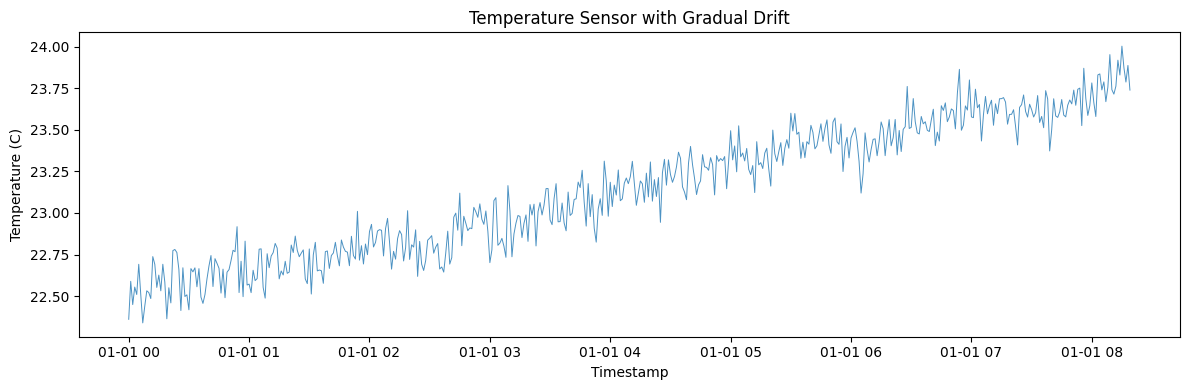

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_temp["ds"].to_list(), df_temp["y"].to_list(), alpha=0.8, linewidth=0.7)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature (C)")
ax.set_title("Temperature Sensor with Gradual Drift")
plt.tight_layout()
plt.show()

In [ ]:
values = df_temp["y"].to_numpy()
print(f"Temperature statistics:")
print(f"  Mean:     {np.mean(values):.2f} C")
print(f"  Min:      {np.min(values):.2f} C")
print(f"  Max:      {np.max(values):.2f} C")
print(f"  Std:      {np.std(values):.2f} C")

first_100 = np.mean(values[:100])
last_100 = np.mean(values[-100:])
print(f"  Drift:    {last_100 - first_100:.2f} C (first 100 vs last 100)")

Temperature statistics:
  Mean:     23.14 C
  Min:      22.34 C
  Max:      24.00 C
  Std:      0.39 C
  Drift:    1.02 C (first 100 vs last 100)


## 2. Humidity sensor with daily cycle

Generate 24 hours of humidity readings at 1-minute intervals with a daily seasonal pattern.

In [ ]:
params_humidity = {
    "min_length": 1440,
    "max_length": 1440,
    "freq": "min",
    "n_sensors": 1,
    "sensor_type": "humidity",
    "base_value": 60.0,
    "seasonal_period": 1440,
    "seasonal_amplitude": 15.0,
    "measurement_noise": 1.0,
    "seed": 123,
}

gen_humidity = IoTSensorGenerator(engine="polars", **params_humidity)
df_humidity = gen_humidity.generate(n_series=1)

print(f"Generated 24 hours of humidity readings (1-minute intervals)")

values_humidity = df_humidity["y"].to_numpy()
print(f"\nHumidity statistics:")
print(f"  Mean:     {np.mean(values_humidity):.1f}%")
print(f"  Min:      {np.min(values_humidity):.1f}%")
print(f"  Max:      {np.max(values_humidity):.1f}%")

df_humidity.filter(pl.col("ds").dt.minute() == 0).filter(
    pl.col("ds").dt.hour() % 2 == 0
).head(12)

Generated 24 hours of humidity readings (1-minute intervals)

Humidity statistics:
  Mean:     60.3%
  Min:      43.1%
  Max:      76.6%


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,58.351737
"""0""",2000-01-01 02:00:00,67.881279
"""0""",2000-01-01 04:00:00,71.417134
"""0""",2000-01-01 06:00:00,75.064438
"""0""",2000-01-01 08:00:00,70.703289
…,…,…
"""0""",2000-01-01 14:00:00,55.208747
"""0""",2000-01-01 16:00:00,47.778869
"""0""",2000-01-01 18:00:00,44.222302


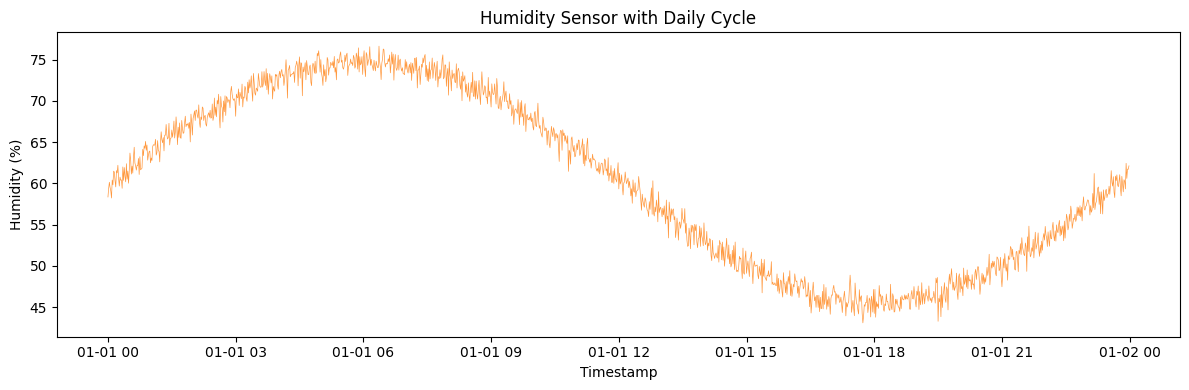

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_humidity["ds"].to_list(), df_humidity["y"].to_list(), alpha=0.8, linewidth=0.5, color="C1")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Humidity (%)")
ax.set_title("Humidity Sensor with Daily Cycle")
plt.tight_layout()
plt.show()

## 3. Pressure sensor with battery degradation

Simulate a pressure sensor where measurement quality degrades as battery life decreases.

In [ ]:
params_pressure = {
    "min_length": 400,
    "max_length": 400,
    "freq": "min",
    "n_sensors": 1,
    "sensor_type": "pressure",
    "base_value": 1013.25,
    "measurement_noise": 0.5,
    "battery_life": 200,
    "battery_degradation_rate": 0.005,
    "seed": 456,
}

gen_pressure = IoTSensorGenerator(engine="polars", **params_pressure)
df_pressure = gen_pressure.generate(n_series=1)

print(f"Generated {len(df_pressure)} pressure readings")
print(f"Battery degradation starts at reading 200")

values_pressure = df_pressure["y"].to_numpy()
first_half_std = np.std(values_pressure[:200])
second_half_std = np.std(values_pressure[200:])

print(f"\nPressure quality:")
print(f"  Before battery degradation (readings 0-200):")
print(f"    Std: {first_half_std:.2f} hPa")
print(f"  After battery degradation (readings 200-400):")
print(f"    Std: {second_half_std:.2f} hPa")
print(f"  Quality degradation: {((second_half_std/first_half_std - 1) * 100):.1f}% increase in noise")

Generated 400 pressure readings
Battery degradation starts at reading 200

Pressure quality:
  Before battery degradation (readings 0-200):
    Std: 0.54 hPa
  After battery degradation (readings 200-400):
    Std: 29.20 hPa
  Quality degradation: 5341.6% increase in noise


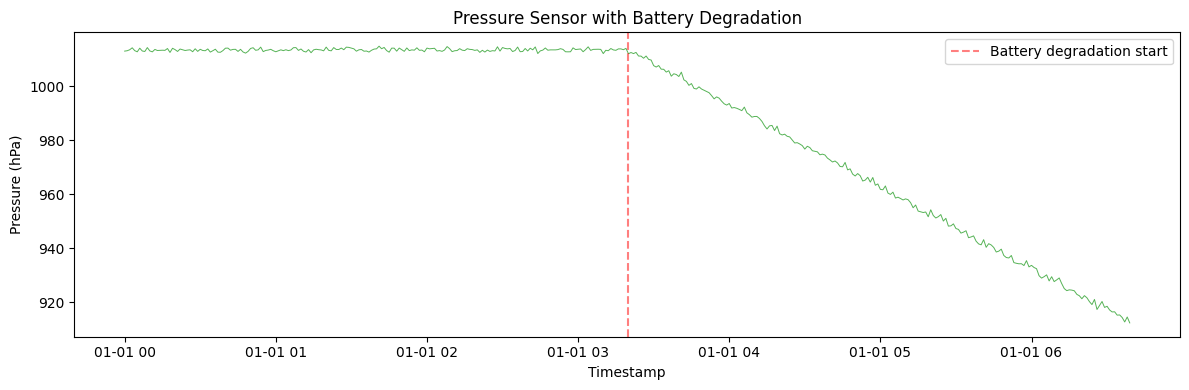

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_pressure["ds"].to_list(), df_pressure["y"].to_list(), alpha=0.8, linewidth=0.7, color="C2")
ax.axvline(x=df_pressure["ds"].to_list()[200], color="red", linestyle="--", alpha=0.5, label="Battery degradation start")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("Pressure Sensor with Battery Degradation")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Light sensor with intermittent failures

Simulate a light sensor that experiences random intermittent outages.

In [ ]:
params_light = {
    "min_length": 300,
    "max_length": 300,
    "freq": "1s",
    "n_sensors": 1,
    "sensor_type": "light",
    "base_value": 800.0,
    "measurement_noise": 10.0,
    "failure_probability": 0.05,
    "failure_type": "intermittent",
    "failure_duration": 5,
    "seed": 789,
}

gen_light = IoTSensorGenerator(engine="polars", **params_light)
df_light = gen_light.generate(n_series=1)

print(f"Generated {len(df_light)} light readings (1-second intervals)")

values_light = df_light["y"].to_numpy()
nan_count = np.sum(np.isnan(values_light))
valid_count = len(values_light) - nan_count

print(f"\nFailure statistics:")
print(f"  Valid readings:   {valid_count} ({valid_count/len(values_light)*100:.1f}%)")
print(f"  Failed readings:  {nan_count} ({nan_count/len(values_light)*100:.1f}%)")

df_light.head(50)

Generated 300 light readings (1-second intervals)

Failure statistics:
  Valid readings:   210 (70.0%)
  Failed readings:  90 (30.0%)


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,794.117333
"""0""",2000-01-01 00:00:01,817.596792
"""0""",2000-01-01 00:00:02,812.608478
"""0""",2000-01-01 00:00:03,775.054655
"""0""",2000-01-01 00:00:04,786.852539
…,…,…
"""0""",2000-01-01 00:00:45,800.829929
"""0""",2000-01-01 00:00:46,805.540488
"""0""",2000-01-01 00:00:47,806.466231


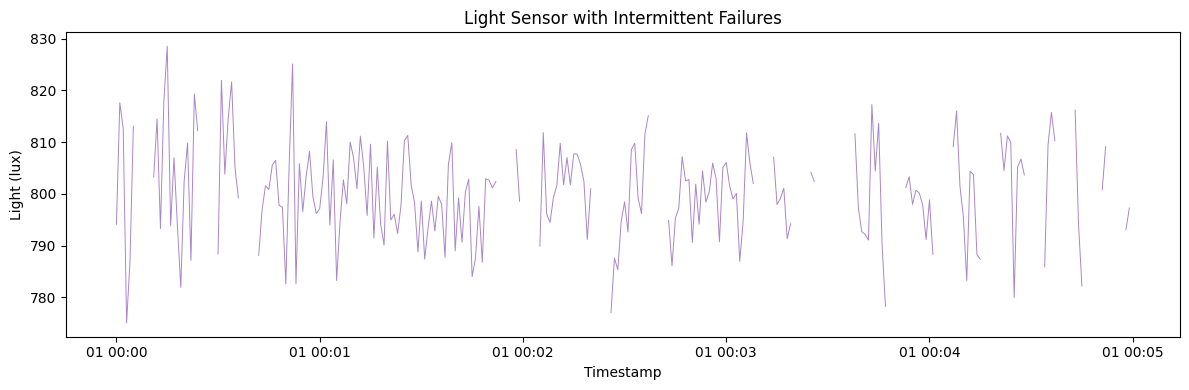

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_light["ds"].to_list(), df_light["y"].to_list(), alpha=0.8, linewidth=0.7, color="C4")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Light (lux)")
ax.set_title("Light Sensor with Intermittent Failures")
plt.tight_layout()
plt.show()

## 5. Temperature sensor network (multivariate)

Generate a network of 4 spatially correlated temperature sensors.

In [ ]:
params_network = {
    "min_length": 200,
    "max_length": 200,
    "freq": "min",
    "n_sensors": 4,
    "sensor_type": "temperature",
    "base_value": 20.0,
    "spatial_correlation": 0.7,
    "measurement_noise": 0.5,
    "seed": 1011,
}

gen_network = IoTSensorGenerator(engine="polars", **params_network)
df_network = gen_network.generate(n_series=1)

print(f"Generated sensor network with {df_network['unique_id'].n_unique()} sensors")
print(f"Total readings: {len(df_network)}")
df_network.head(30)

Generated sensor network with 4 sensors
Total readings: 800


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,20.452877
"""0""",2000-01-01 00:01:00,19.287093
"""0""",2000-01-01 00:02:00,19.120498
"""0""",2000-01-01 00:03:00,21.071625
"""0""",2000-01-01 00:04:00,20.195943
…,…,…
"""0""",2000-01-01 00:25:00,19.595728
"""0""",2000-01-01 00:26:00,20.554394
"""0""",2000-01-01 00:27:00,19.770506


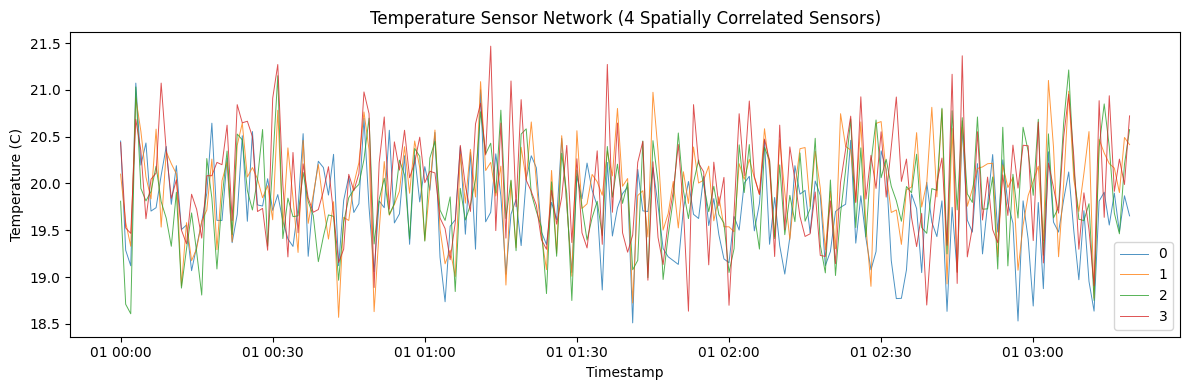

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_network["unique_id"].unique().to_list():
    series = df_network.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8, linewidth=0.7)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature (C)")
ax.set_title("Temperature Sensor Network (4 Spatially Correlated Sensors)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
sensor_0 = df_network.filter(pl.col("unique_id") == "0")["y"].to_numpy()
sensor_1 = df_network.filter(pl.col("unique_id") == "1")["y"].to_numpy()
sensor_2 = df_network.filter(pl.col("unique_id") == "2")["y"].to_numpy()
sensor_3 = df_network.filter(pl.col("unique_id") == "3")["y"].to_numpy()

corr_01 = np.corrcoef(sensor_0, sensor_1)[0, 1]
corr_12 = np.corrcoef(sensor_1, sensor_2)[0, 1]
corr_23 = np.corrcoef(sensor_2, sensor_3)[0, 1]
corr_03 = np.corrcoef(sensor_0, sensor_3)[0, 1]

print(f"Spatial correlation between sensors:")
print(f"  Sensor 0 <-> Sensor 1 (adjacent):  {corr_01:.3f}")
print(f"  Sensor 1 <-> Sensor 2 (adjacent):  {corr_12:.3f}")
print(f"  Sensor 2 <-> Sensor 3 (adjacent):  {corr_23:.3f}")
print(f"  Sensor 0 <-> Sensor 3 (distant):   {corr_03:.3f}")

Spatial correlation between sensors:
  Sensor 0 <-> Sensor 1 (adjacent):  0.588
  Sensor 1 <-> Sensor 2 (adjacent):  0.683
  Sensor 2 <-> Sensor 3 (adjacent):  0.668
  Sensor 0 <-> Sensor 3 (distant):   0.338


## 6. Motion sensor with complete failure

Simulate a motion sensor that may experience a complete failure, after which all readings are lost.

In [ ]:
params_motion = {
    "min_length": 200,
    "max_length": 200,
    "freq": "100ms",
    "n_sensors": 1,
    "sensor_type": "motion",
    "base_value": 0.5,
    "measurement_noise": 0.2,
    "failure_probability": 0.3,
    "failure_type": "complete",
    "seed": 1213,
}

gen_motion = IoTSensorGenerator(engine="polars", **params_motion)
df_motion = gen_motion.generate(n_series=1)

print(f"Generated {len(df_motion)} motion sensor readings (100ms intervals)")

values_motion = df_motion["y"].to_numpy()
nan_count_motion = np.sum(np.isnan(values_motion))

if nan_count_motion > 0:
    first_nan = np.where(np.isnan(values_motion))[0][0]
    print(f"\nSensor failed at reading {first_nan}")
    print(f"Valid readings before failure: {first_nan}")
    print(f"Failed readings after failure: {nan_count_motion}")
else:
    print(f"\nSensor operated normally (no failure occurred)")

Generated 200 motion sensor readings (100ms intervals)

Sensor failed at reading 0
Valid readings before failure: 0
Failed readings after failure: 200


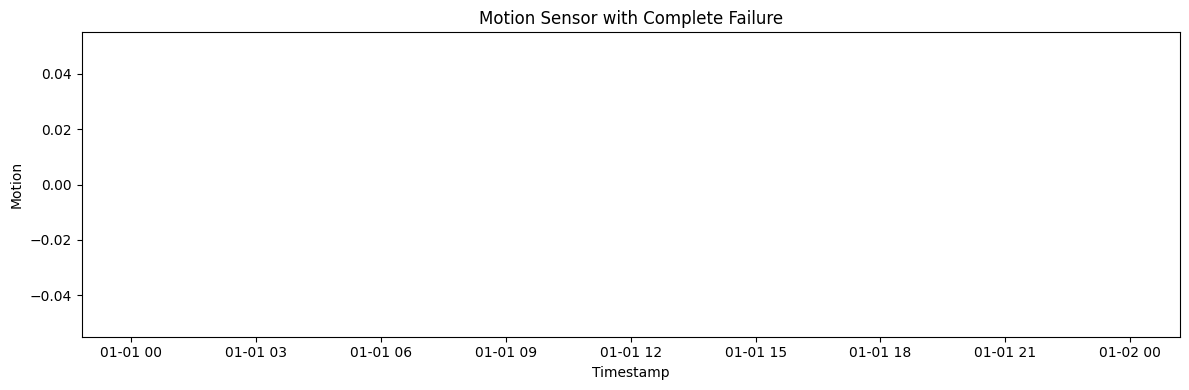

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_motion["ds"].to_list(), df_motion["y"].to_list(), alpha=0.8, linewidth=0.7, color="C5")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Motion")
ax.set_title("Motion Sensor with Complete Failure")
plt.tight_layout()
plt.show()

## 7. Multiple independent temperature sensors

Generate multiple independent sensors using the univariate mode.

In [ ]:
params_multi = {
    "min_length": 100,
    "max_length": 100,
    "freq": "min",
    "n_sensors": 1,
    "sensor_type": "temperature",
    "base_value": 20.0,
    "measurement_noise": 0.3,
    "seed": 1415,
}

gen_multi = IoTSensorGenerator(engine="polars", **params_multi)
df_multi = gen_multi.generate(n_series=3)

print(f"Generated {df_multi['unique_id'].n_unique()} independent sensors")
print(f"\nStatistics per sensor:")
for series_id in df_multi["unique_id"].unique().sort():
    series_df = df_multi.filter(pl.col("unique_id") == series_id)
    values_series = series_df["y"].to_numpy()
    print(
        f"  {series_id}: Mean={np.mean(values_series):.2f} C, Std={np.std(values_series):.2f} C"
    )

Generated 3 independent sensors

Statistics per sensor:
  0: Mean=20.01 C, Std=0.35 C
  1: Mean=19.96 C, Std=0.27 C
  2: Mean=19.95 C, Std=0.28 C


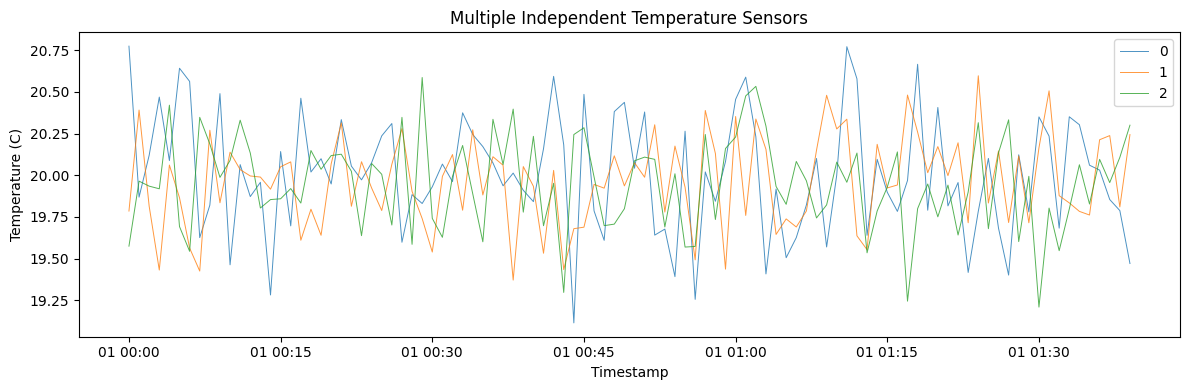

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_multi["unique_id"].unique().to_list():
    series = df_multi.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8, linewidth=0.7)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Temperature (C)")
ax.set_title("Multiple Independent Temperature Sensors")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Anomalies](../../capabilities/anomalies) — inject labelled outliers on top of any generator.
- [Missingness](../../capabilities/missingness) — dropout gaps from outages.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::